In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

Reminder of what the data looks like...

In [2]:
df = pd.read_csv('sensor.csv')
print("Dataset Shape:", df.shape)
print("\nFirst few rows of the dataset:")
df.head()

Dataset Shape: (220320, 55)

First few rows of the dataset:


,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


VAR w/ 3 sensors : `sensor_10`, `sensor_36`, `sensor_48`

In [ ]:
import pandas as pd

# Load and preprocess data
df = pd.read_csv('sensor.csv')
#print(df.head())
print("Is there missing data in the dataset? ", pd.isna(df).any().any())
# Drop columns that are completely empty
df = df.dropna(axis=1, how='all')
"""# Step 2: Drop columns with more than 50% missing values
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)"""
# Forward-fill and back-fill remaining missing values (only on sensor columns)
sensor_cols = [col for col in df.columns if col.startswith("sensor_")]
df[sensor_cols] = df[sensor_cols].ffill().bfill()
# Drop any rows that still have NaNs (if any)
df = df.dropna()
# Only keep sensors 10, 36 and 48
df = df[['sensor_10', 'sensor_36', 'sensor_48', 'machine_status']]

# Final check
print("Any NaNs left?", df.isna().any().any())  # Should print False
print("Final shape:", df.shape)

sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
df_normal = df[df['machine_status'] == 'NORMAL']

Is there missing data in the dataset?  True
Any NaNs left? False
Final shape: (220320, 4)


In [4]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Standardize sensor data
scaler = StandardScaler()
df_normal[sensor_cols] = scaler.fit_transform(df_normal[sensor_cols])

# Fit VAR model
model = VAR(df_normal[sensor_cols])
results = model.fit(maxlags=10, ic='aic')
print(results.summary())

# Forecast and compute residuals on full dataset
# All data is scaled using the statistics from the normal data only
df[sensor_cols] = scaler.transform(df[sensor_cols])
# Our lag order 
lag_order = results.k_ar
print("Lag order is ", lag_order)
# Extract the first lag_order rows of your (scaled) sensor data
forecast_input = df[sensor_cols].values[:lag_order]
# Forecast the next len(df) - lag_order time steps, starting from the initial forecast_input
forecasted = results.forecast(y=forecast_input, steps=len(df) - lag_order)
# Calculate the residuals (errors) for each time point and each sensor by subtracting the VAR model’s predicted values (forecasted) from the actual observed sensor values
residuals = df[sensor_cols].values[lag_order:] - forecasted
# Square the residuals (to emphasize larger errors and ignore sign), then sum across all sensors to get a single anomaly score for each time point
anomaly_score = (residuals ** 2).sum(axis=1)

# Detect anomalies
# Our threshold
threshold = anomaly_score.mean() + anomaly_score.std()
# New column for anomalies (0 or 1)
df['anomaly'] = 0
# All rows from lag_order onward (the rows where you have an anomaly score), you set 'anomaly' to 1 if the anomaly score is greater than the threshold, otherwise it remains 0
df.loc[lag_order:, 'anomaly'] = (anomaly_score > threshold).astype(int)

# Evaluation of our model
true_anomalies = (df['machine_status'] != 'NORMAL').astype(int)
precision = precision_score(true_anomalies[lag_order:], df['anomaly'][lag_order:])
recall = recall_score(true_anomalies[lag_order:], df['anomaly'][lag_order:])
f1 = f1_score(true_anomalies[lag_order:], df['anomaly'][lag_order:])
percent_found = 100 * df.loc[(df['anomaly'] == 1) & (true_anomalies == 1)].shape[0] / true_anomalies.sum()

print(f"🔧 Precision: {precision:.3f}")
print(f"🔧 Recall:    {recall:.3f}")
print(f"🔧 F1 Score:  {f1:.3f}")
print(f"🔧 % Found:   {percent_found:.2f}%")


C:\Users\USER\AppData\Local\Temp\ipykernel_22948\3874306871.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_normal[sensor_cols] = scaler.fit_transform(df_normal[sensor_cols])
c:\Dave\Apps\miniconda3.9\envs\t-s\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 12, Jul, 2025
Time:                     13:33:57
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -17.1287
Nobs:                     205826.    HQIC:                  -17.1320
Log likelihood:           887173.    FPE:                3.62313e-08
AIC:                     -17.1333    Det(Omega_mle):     3.62150e-08
--------------------------------------------------------------------
Results for equation sensor_10
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.000003         0.000323            0.010           0.992
L1.sensor_10          1.065124         0.002204          483.219           0.000
L1.sensor_36         -0.021755         0.009582         

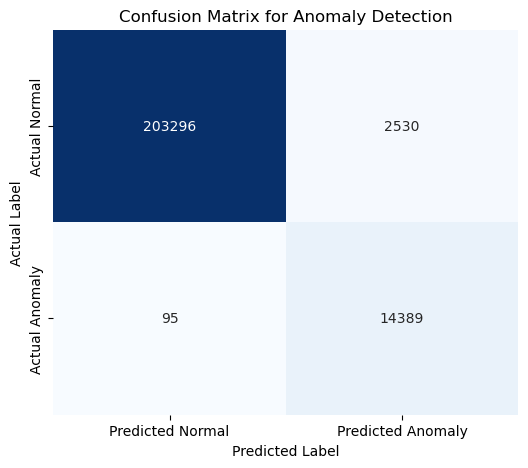

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# true_anomalies and df['anomaly'] should be 1D arrays of 0 (normal) and 1 (anomaly)
cm = confusion_matrix(true_anomalies[lag_order:], df['anomaly'][lag_order:])

# Define labels for axes and cells
labels = ['Normal', 'Anomaly']
cm_df = pd.DataFrame(cm, index=['Actual Normal', 'Actual Anomaly'],
                         columns=['Predicted Normal', 'Predicted Anomaly'])

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Anomaly Detection')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

Visualization of anomalies (green = true anomaly, red = false positive, orange = false negative)

Sensor 10

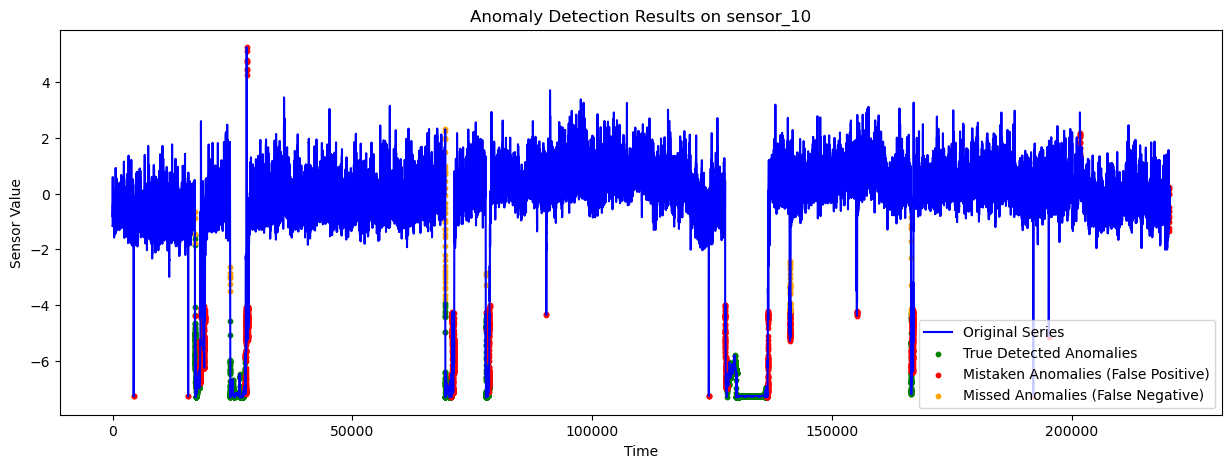

In [9]:
import numpy as np
import matplotlib.pyplot as plt

sensor_name = 'sensor_10'  # Change to any sensor you want to visualize
sensor_series = df[sensor_name]

# True and predicted labels after lag_order
true_labels = true_anomalies[lag_order:].values
pred_labels = df['anomaly'][lag_order:].values

# Find indices for each case
TP_idx = np.where((true_labels == 1) & (pred_labels == 1))[0]
FP_idx = np.where((true_labels == 0) & (pred_labels == 1))[0]
FN_idx = np.where((true_labels == 1) & (pred_labels == 0))[0]

# Map to DataFrame indices
indices = df.index[lag_order:]
TP_indices = indices[TP_idx]
FP_indices = indices[FP_idx]
FN_indices = indices[FN_idx]

plt.figure(figsize=(15, 5))
plt.plot(sensor_series, label='Original Series', color='blue')
plt.scatter(TP_indices, sensor_series.loc[TP_indices], color='green', label='True Detected Anomalies', s=10)
plt.scatter(FP_indices, sensor_series.loc[FP_indices], color='red', label='Mistaken Anomalies (False Positive)', s=10)
plt.scatter(FN_indices, sensor_series.loc[FN_indices], color='orange', label='Missed Anomalies (False Negative)', s=10)
plt.legend()
plt.title(f'Anomaly Detection Results on {sensor_name}')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.show()


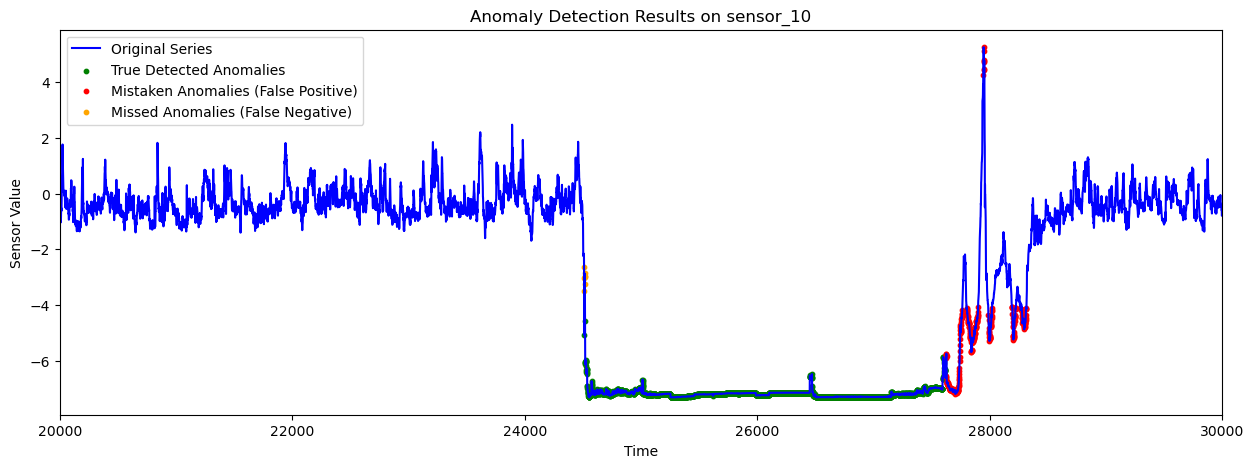

In [10]:
import numpy as np
import matplotlib.pyplot as plt

sensor_name = 'sensor_10'  # Change to any sensor you want to visualize
sensor_series = df[sensor_name]

# True and predicted labels after lag_order
true_labels = true_anomalies[lag_order:].values
pred_labels = df['anomaly'][lag_order:].values

# Find indices for each case
TP_idx = np.where((true_labels == 1) & (pred_labels == 1))[0]
FP_idx = np.where((true_labels == 0) & (pred_labels == 1))[0]
FN_idx = np.where((true_labels == 1) & (pred_labels == 0))[0]

# Map to DataFrame indices
indices = df.index[lag_order:]
TP_indices = indices[TP_idx]
FP_indices = indices[FP_idx]
FN_indices = indices[FN_idx]

plt.figure(figsize=(15, 5))
plt.plot(sensor_series, label='Original Series', color='blue')
plt.scatter(TP_indices, sensor_series.loc[TP_indices], color='green', label='True Detected Anomalies', s=10)
plt.scatter(FP_indices, sensor_series.loc[FP_indices], color='red', label='Mistaken Anomalies (False Positive)', s=10)
plt.scatter(FN_indices, sensor_series.loc[FN_indices], color='orange', label='Missed Anomalies (False Negative)', s=10)
plt.legend()
plt.title(f'Anomaly Detection Results on {sensor_name}')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.xlim(20000, 30000)
plt.show()


Sensor 36

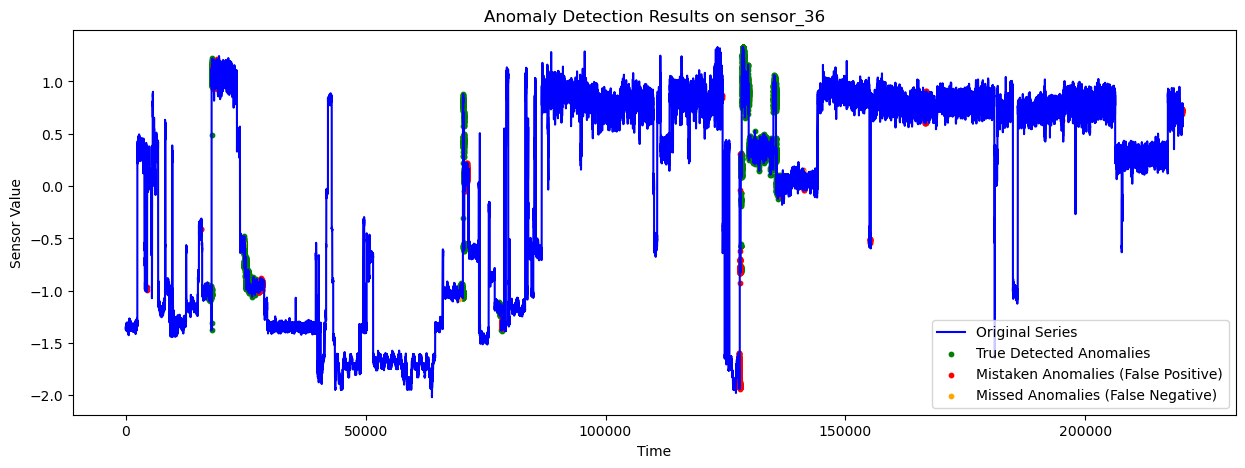

In [ ]:
sensor_name = 'sensor_36'  # Change to any sensor you want to visualize
sensor_series = df[sensor_name]

# True and predicted labels after lag_order
true_labels = true_anomalies[lag_order:].values
pred_labels = df['anomaly'][lag_order:].values

# Find indices for each case
TP_idx = np.where((true_labels == 1) & (pred_labels == 1))[0]
FP_idx = np.where((true_labels == 0) & (pred_labels == 1))[0]
FN_idx = np.where((true_labels == 1) & (pred_labels == 0))[0]

# Map to DataFrame indices
indices = df.index[lag_order:]
TP_indices = indices[TP_idx]
FP_indices = indices[FP_idx]
FN_indices = indices[FN_idx]

plt.figure(figsize=(15, 5))
plt.plot(sensor_series, label='Original Series', color='blue')
plt.scatter(TP_indices, sensor_series.loc[TP_indices], color='green', label='True Detected Anomalies', s=10)
plt.scatter(FP_indices, sensor_series.loc[FP_indices], color='red', label='Mistaken Anomalies (False Positive)', s=10)
plt.scatter(FN_indices, sensor_series.loc[FN_indices], color='orange', label='Missed Anomalies (False Negative)', s=10)
plt.legend()
plt.title(f'Anomaly Detection Results on {sensor_name}')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.show()


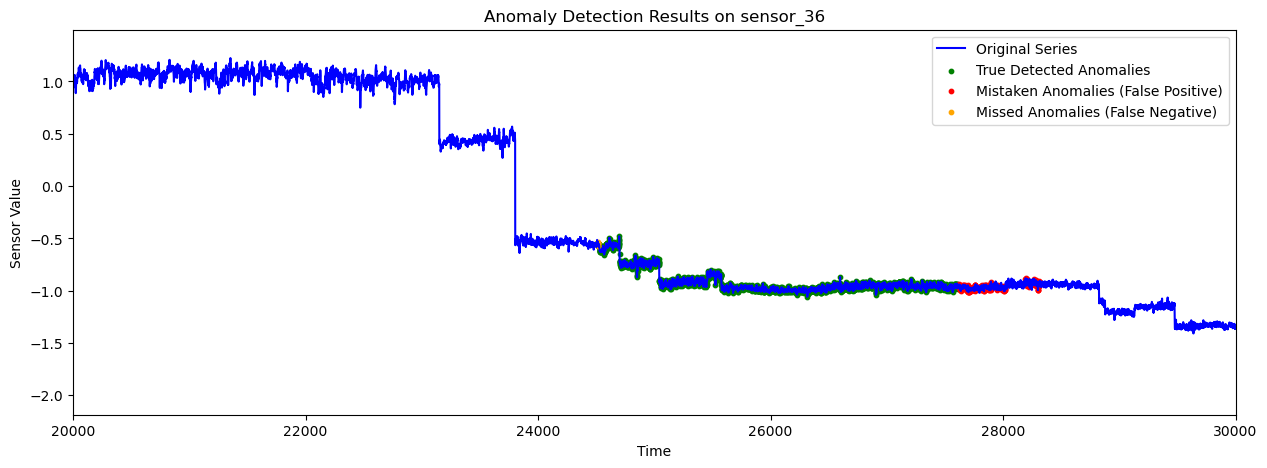

In [12]:
sensor_name = 'sensor_36'  # Change to any sensor you want to visualize
sensor_series = df[sensor_name]

# True and predicted labels after lag_order
true_labels = true_anomalies[lag_order:].values
pred_labels = df['anomaly'][lag_order:].values

# Find indices for each case
TP_idx = np.where((true_labels == 1) & (pred_labels == 1))[0]
FP_idx = np.where((true_labels == 0) & (pred_labels == 1))[0]
FN_idx = np.where((true_labels == 1) & (pred_labels == 0))[0]

# Map to DataFrame indices
indices = df.index[lag_order:]
TP_indices = indices[TP_idx]
FP_indices = indices[FP_idx]
FN_indices = indices[FN_idx]

plt.figure(figsize=(15, 5))
plt.plot(sensor_series, label='Original Series', color='blue')
plt.scatter(TP_indices, sensor_series.loc[TP_indices], color='green', label='True Detected Anomalies', s=10)
plt.scatter(FP_indices, sensor_series.loc[FP_indices], color='red', label='Mistaken Anomalies (False Positive)', s=10)
plt.scatter(FN_indices, sensor_series.loc[FN_indices], color='orange', label='Missed Anomalies (False Negative)', s=10)
plt.legend()
plt.title(f'Anomaly Detection Results on {sensor_name}')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.xlim(20000, 30000)
plt.show()


Sensor 48

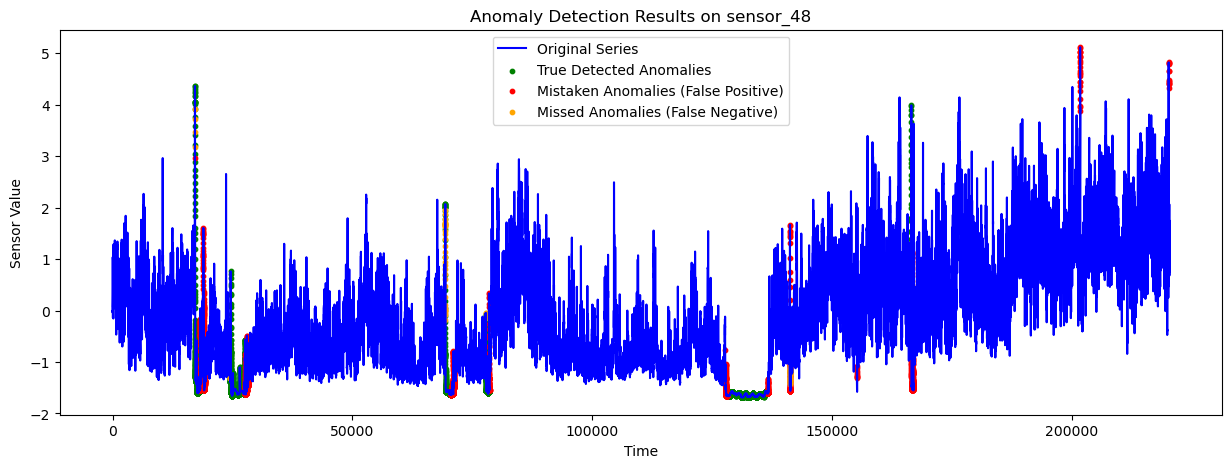

In [13]:
sensor_name = 'sensor_48'  # Change to any sensor you want to visualize
sensor_series = df[sensor_name]

# True and predicted labels after lag_order
true_labels = true_anomalies[lag_order:].values
pred_labels = df['anomaly'][lag_order:].values

# Find indices for each case
TP_idx = np.where((true_labels == 1) & (pred_labels == 1))[0]
FP_idx = np.where((true_labels == 0) & (pred_labels == 1))[0]
FN_idx = np.where((true_labels == 1) & (pred_labels == 0))[0]

# Map to DataFrame indices
indices = df.index[lag_order:]
TP_indices = indices[TP_idx]
FP_indices = indices[FP_idx]
FN_indices = indices[FN_idx]

plt.figure(figsize=(15, 5))
plt.plot(sensor_series, label='Original Series', color='blue')
plt.scatter(TP_indices, sensor_series.loc[TP_indices], color='green', label='True Detected Anomalies', s=10)
plt.scatter(FP_indices, sensor_series.loc[FP_indices], color='red', label='Mistaken Anomalies (False Positive)', s=10)
plt.scatter(FN_indices, sensor_series.loc[FN_indices], color='orange', label='Missed Anomalies (False Negative)', s=10)
plt.legend()
plt.title(f'Anomaly Detection Results on {sensor_name}')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.show()


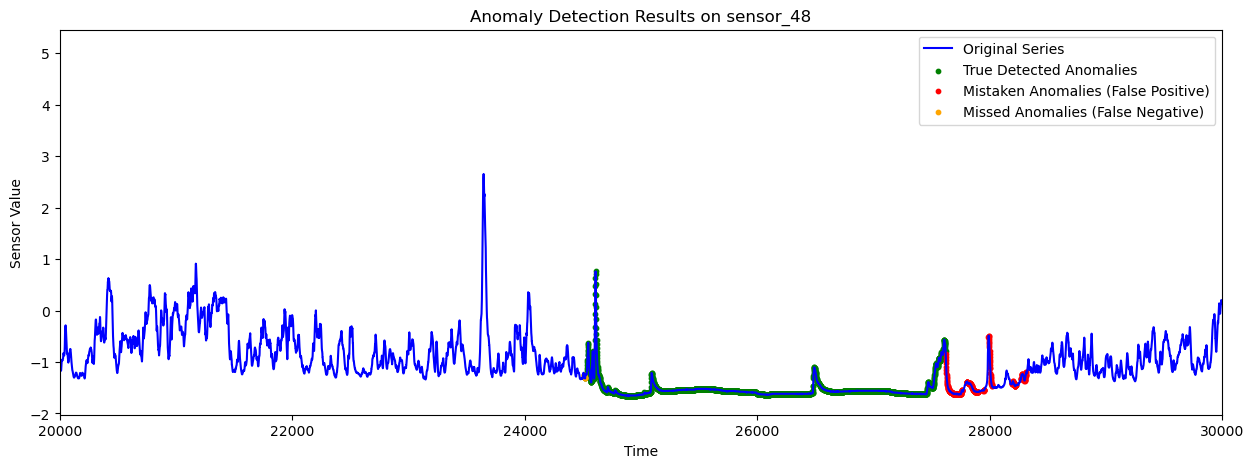

In [14]:
sensor_name = 'sensor_48'
sensor_series = df[sensor_name]

# True and predicted labels after lag_order
true_labels = true_anomalies[lag_order:].values
pred_labels = df['anomaly'][lag_order:].values

# Find indices for each case
TP_idx = np.where((true_labels == 1) & (pred_labels == 1))[0]
FP_idx = np.where((true_labels == 0) & (pred_labels == 1))[0]
FN_idx = np.where((true_labels == 1) & (pred_labels == 0))[0]

# Map to DataFrame indices
indices = df.index[lag_order:]
TP_indices = indices[TP_idx]
FP_indices = indices[FP_idx]
FN_indices = indices[FN_idx]

plt.figure(figsize=(15, 5))
plt.plot(sensor_series, label='Original Series', color='blue')
plt.scatter(TP_indices, sensor_series.loc[TP_indices], color='green', label='True Detected Anomalies', s=10)
plt.scatter(FP_indices, sensor_series.loc[FP_indices], color='red', label='Mistaken Anomalies (False Positive)', s=10)
plt.scatter(FN_indices, sensor_series.loc[FN_indices], color='orange', label='Missed Anomalies (False Negative)', s=10)
plt.legend()
plt.title(f'Anomaly Detection Results on {sensor_name}')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.xlim(20000, 30000)
plt.show()
